<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_20520/44217147.py:47: SyntaxWarning: invalid escape sequence '\s'
  labels = ['Deterministic ($\sigma=0$)', 'Weak Noise ($\sigma=0.15$)', 'Strong Noise ($\sigma=0.4$)']
/tmp/ipykernel_20520/44217147.py:47: SyntaxWarning: invalid escape sequence '\s'
  labels = ['Deterministic ($\sigma=0$)', 'Weak Noise ($\sigma=0.15$)', 'Strong Noise ($\sigma=0.4$)']
/tmp/ipykernel_20520/44217147.py:47: SyntaxWarning: invalid escape sequence '\s'
  labels = ['Deterministic ($\sigma=0$)',

Simulating sigma = 0.4: 100%|██████████| 25/25 [00:05<00:00,  4.36it/s]


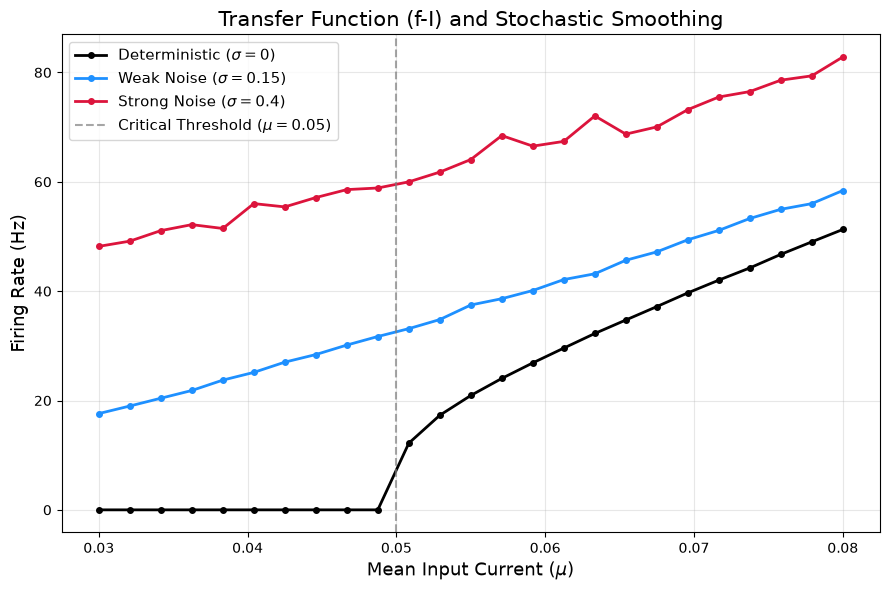

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from tqdm import tqdm

sys.path.append(os.path.abspath(os.path.join('..')))
from src.engine import simulate_first_passage_times

# Parameters
mu_values = np.linspace(0.03, 0.08, 25)

# three scenarios: deterministic, weak noise, strong noise
sigma_values = [0.0, 0.15, 0.4] 

n_pop = 5000    # neurons for each condition
t_max = 2000.0  # max time in ms for each simulation

firing_rates = {}

# simulation
for sigma in sigma_values:
    rates_for_sigma = []
    
    for mu in tqdm(mu_values, desc=f"Simulating sigma = {sigma}"):
        
        fpt_results = simulate_first_passage_times(
            mu=mu, sigma=sigma, n_neurons=n_pop, t_max=t_max
        )
        
        # Nan filtering
        valid_fpt = fpt_results[~np.isnan(fpt_results)]
        
        if len(valid_fpt) > 0:
            mean_fpt = np.mean(valid_fpt)
            rate_hz = 1000.0 / mean_fpt  # ms to Hz
        else:
            rate_hz = 0.0
            
        rates_for_sigma.append(rate_hz)
        
    firing_rates[sigma] = rates_for_sigma

plt.figure(figsize=(9, 6))

colors = ['black', 'dodgerblue', 'crimson']
labels = ['Deterministic ($\sigma=0$)', 'Weak Noise ($\sigma=0.15$)', 'Strong Noise ($\sigma=0.4$)']

for sigma, color, label in zip(sigma_values, colors, labels):
    plt.plot(mu_values, firing_rates[sigma], marker='o', markersize=4, 
             linewidth=2, color=color, label=label)

plt.axvline(x=0.05, color='gray', linestyle='--', alpha=0.7, label='Critical Threshold ($\mu = 0.05$)')

plt.title("Transfer Function (f-I) and Stochastic Smoothing", fontsize=15)
plt.xlabel("Mean Input Current ($\mu$)", fontsize=13)
plt.ylabel("Firing Rate (Hz)", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_20520/2650149168.py:8: SyntaxWarning: invalid escape sequence '\s'
  labels = ['$\sigma=0.0$', '$\sigma=0.15$', '$\sigma=0.4$']
/tmp/ipykernel_20520/2650149168.py:8: SyntaxWarning: invalid escape sequence '\s'
  labels = ['$\sigma=0.0$', '$\sigma=0.15$', '$\sigma=0.4$']
/tmp/ipykernel_20520/2650149168.py:8: SyntaxWarning: invalid escape sequence '\s'
  labels = ['$\sigma=0.0$', '$\sigma=0.15$', '$\sigma=0.4$']
/tmp/ipykernel_20520/2650149168.py:25: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Mean Input Current ($\mu$)", fontsize=13)


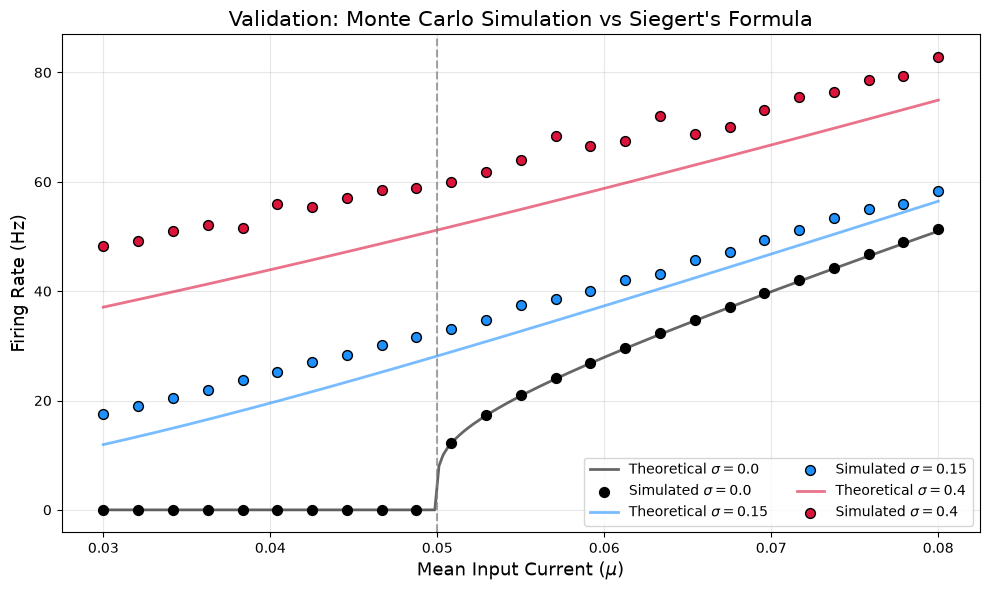

In [8]:
from src.theory import siegert_firing_rate

mu_teorico = np.linspace(0.03, 0.08, 200)

plt.figure(figsize=(10, 6))

colors = ['black', 'dodgerblue', 'crimson']
labels = ['$\sigma=0.0$', '$\sigma=0.15$', '$\sigma=0.4$']

for sigma, color, label in zip(sigma_values, colors, labels):
    
    # theoretical curve for the current sigma (Siegert's formula)
    rate_teorico = [siegert_firing_rate(m, sigma) for m in mu_teorico]
    
    plt.plot(mu_teorico, rate_teorico, color=color, linewidth=2, 
             alpha=0.6, label=f'Theoretical {label}')
    
    # scatter for simulated points
    plt.scatter(mu_values, firing_rates[sigma], color=color, edgecolor='black', 
                zorder=5, s=50, label=f'Simulated {label}')

plt.axvline(x=0.05, color='gray', linestyle='--', alpha=0.7)

plt.title("Validation: Monte Carlo Simulation vs Siegert's Formula", fontsize=15)
plt.xlabel("Mean Input Current ($\mu$)", fontsize=13)
plt.ylabel("Firing Rate (Hz)", fontsize=13)

plt.legend(fontsize=10, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()